In [1]:
#Importamos librerias de interes (no hace falta utilizar todas)
import pandas as pd
import numpy as np
from pathlib import Path
import re
import seaborn as sns
import matplotlib.pyplot as plt
import html
from textblob import TextBlob

### Cargo el Dataset 

In [2]:
RANDOM_STATE = 7

DATA_DIR = Path(".")

dataset_path = DATA_DIR / "training.1600000.processed.noemoticon.csv"

columnas = [
    "sentiment",
    "tweet_id",
    "date",
    "query",
    "user",
    "text"
]

df = pd.read_csv(
    dataset_path,
    encoding="latin-1",
    header=None,
    names=columnas
)

print("Dimensiones:", df.shape)
display(df.head())

Dimensiones: (1600000, 6)


,sentiment,tweet_id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


### Preparación de Datos

In [3]:
print(df.info())

print("\nValores nulos:")
print(df.isna().sum())

print("\nDistribución de sentimientos:")
print(df["sentiment"].value_counts())

print("\nDuplicados:")
print("Por ID:", df["tweet_id"].duplicated().sum())
print("Por texto:", df["text"].duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   sentiment  1600000 non-null  int64
 1   tweet_id   1600000 non-null  int64
 2   date       1600000 non-null  str  
 3   query      1600000 non-null  str  
 4   user       1600000 non-null  str  
 5   text       1600000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 256.9 MB
None

Valores nulos:
sentiment    0
tweet_id     0
date         0
query        0
user         0
text         0
dtype: int64

Distribución de sentimientos:
sentiment
0    800000
4    800000
Name: count, dtype: int64

Duplicados:
Por ID: 1685


Por texto: 18534


In [4]:
resumen_ids = (
    df.groupby("tweet_id")
    .agg(
        cantidad_filas=("tweet_id", "size"),
        textos_distintos=("text", "nunique"),
        etiquetas_distintas=("sentiment", "nunique")
    )
)

display(resumen_ids[resumen_ids["cantidad_filas"] > 1].head())

,cantidad_filas,textos_distintos,etiquetas_distintas
tweet_id,,,
1467863684,2,1,2
1467880442,2,1,2
1468053611,2,1,2
1468100580,2,1,2
1468115720,2,1,2


In [5]:
print("Cantidad original:", len(df))

# Textos que aparecen con más de una etiqueta
textos_conflictivos = (
    df.groupby("text")["sentiment"]
    .nunique()
)

textos_conflictivos = textos_conflictivos[
    textos_conflictivos > 1
].index

# Eliminar todas las filas de esos textos contradictorios
df_limpio = df[
    ~df["text"].isin(textos_conflictivos)
].copy()

# Eliminar solamente filas completamente repetidas
df_limpio = df_limpio.drop_duplicates(
    subset=["tweet_id", "text", "sentiment"]
).copy()

print("Textos conflictivos:", len(textos_conflictivos))
print("Cantidad final:", len(df_limpio))
print("Filas eliminadas:", len(df) - len(df_limpio))

Cantidad original: 1600000


Textos conflictivos: 2225
Cantidad final: 1593105
Filas eliminadas: 6895


### Tratamiento de duplicados y etiquetas contradictorias

Durante la revisión del dataset encontre algunos textos que aparecían más de una vez, pero con etiquetas de sentimiento diferentes. Es decir, el mismo tweet figuraba en algunos casos como negativo (`0`) y también como positivo (`4`).

Como esos registros le dan información contradictoria al modelo, decidi eliminarlos por completo.

Después también elimine las filas que estaban completamente repetidas, es decir, aquellas que tenían el mismo `tweet_id` y se conservaron los textos repetidos que pertenecían a tweets distintos y tenían una etiqueta consistente.

In [6]:
etiquetas_sentimiento = {
    0: "negativo",
    4: "positivo"
}

resumen_clases = (
    df_limpio["sentiment"]
    .value_counts()
    .sort_index()
    .rename_axis("sentiment")
    .reset_index(name="cantidad")
)

resumen_clases["clase"] = resumen_clases["sentiment"].map(
    etiquetas_sentimiento
)

resumen_clases["porcentaje"] = (
    resumen_clases["cantidad"] / len(df_limpio) * 100
).round(2)

display(
    resumen_clases[
        ["sentiment", "clase", "cantidad", "porcentaje"]
    ]
)

,sentiment,clase,cantidad,porcentaje
0,0,negativo,796303,49.98
1,4,positivo,796802,50.02


### Distribución de clases
El dataset contiene dos etiquetas de sentimiento:

- `0`: negativo.
- `4`: positivo.

La distribución se mantiene aproximadamente balanceada, ya que la cantidad de tweets positivos y negativos es similar. Esto es conveniente para el entrenamiento, porque evita que el modelo tenga una cantidad mucho mayor de ejemplos de una clase que de la otra.

## EDA

In [7]:
df_eda = df_limpio.copy()

### Análisis exploratorio de datos
Se crearon variables para analizar la longitud, cantidad de palabras, hashtags, menciones, URLs, signos y uso de mayúsculas en los tweets.

El objetivo es identificar diferencias entre tweets positivos y negativos más allá del contenido textual.

In [8]:
etiquetas_sentimiento = {
    0: "negativo",
    4: "positivo"
}

df_eda["clase"] = df_eda["sentiment"].map(etiquetas_sentimiento)
df_eda["longitud_caracteres"] = df_eda["text"].astype(str).str.len()

df_eda["cantidad_palabras"] = (
    df_eda["text"]
    .astype(str)
    .str.split()
    .str.len()
)

df_eda["cantidad_hashtags"] = (
    df_eda["text"]
    .astype(str)
    .str.count(r"#\w+")
)

df_eda["cantidad_menciones"] = (
    df_eda["text"]
    .astype(str)
    .str.count(r"@\w+")
)

df_eda["tiene_url"] = (
    df_eda["text"]
    .astype(str)
    .str.contains(r"https?://|www\.", regex=True)
    .astype(int)
)

df_eda["cantidad_exclamaciones"] = (
    df_eda["text"]
    .astype(str)
    .str.count(r"!")
)

df_eda["cantidad_preguntas"] = (
    df_eda["text"]
    .astype(str)
    .str.count(r"\?")
)

df_eda["cantidad_mayusculas"] = (
    df_eda["text"]
    .astype(str)
    .str.count(r"[A-Z]")
)

df_eda["ratio_mayusculas"] = (
    df_eda["cantidad_mayusculas"]
    / df_eda["longitud_caracteres"].replace(0, np.nan)
).fillna(0)
pd.set_option("display.max_colwidth", None)
display(
    df_eda[[
        "sentiment",
        "clase",
        "longitud_caracteres",
        "cantidad_palabras",
        "cantidad_hashtags",
        "cantidad_menciones",
        "tiene_url",
        "cantidad_exclamaciones",
        "cantidad_preguntas",
        "ratio_mayusculas",
        "text"
    ]].sample(n=10, random_state=42)
)

,sentiment,clase,longitud_caracteres,cantidad_palabras,cantidad_hashtags,cantidad_menciones,tiene_url,cantidad_exclamaciones,cantidad_preguntas,ratio_mayusculas,text
1235490,4,positivo,44,5,0,0,1,0,0,0.113636,Calling all crafty bugs http://bit.ly/NKCDt
202162,0,negativo,42,5,0,1,0,7,0,0.095238,.@architeuth1s she's gone man!!! GONE!!!!
1020561,4,positivo,52,7,0,1,0,1,1,0.038462,@davejmatthews good morning! Coffee? Yes have some.
624188,0,negativo,92,17,0,0,0,0,0,0.000000,"media test today arrghhh. i wont be on a computer until after school, so no twitter updates"
762367,0,negativo,80,14,0,0,0,2,0,0.000000,mosquitoes eating my alive! while indoors! this sucks. and still no word on job
14773,0,negativo,42,7,0,0,0,0,0,0.047619,Its finished now i cried. Brillant movie
1257359,4,positivo,80,15,0,1,0,1,0,0.112500,@claymuse Oh man I LOVE good eats! fulfills my need for trivia AND good cooking
664792,0,negativo,52,11,0,0,0,0,0,0.038462,"At home, pretty worried. It sucks to not have a car"
732775,0,negativo,18,3,0,1,0,0,0,0.055556,@iRachey poor rai
713487,0,negativo,58,13,0,0,0,0,0,0.000000,going to bed paris 2moz will be my last tweet for a week


In [9]:
columnas_resumen = [
    "longitud_caracteres",
    "cantidad_palabras",
    "cantidad_hashtags",
    "cantidad_menciones",
    "tiene_url",
    "cantidad_exclamaciones",
    "cantidad_preguntas",
    "ratio_mayusculas"
]

resumen_texto = (
    df_eda
    .groupby("clase")[columnas_resumen]
    .mean()
    .round(3)
)

display(resumen_texto)

,longitud_caracteres,cantidad_palabras,cantidad_hashtags,cantidad_menciones,tiene_url,cantidad_exclamaciones,cantidad_preguntas,ratio_mayusculas
clase,,,,,,,,
negativo,74.405,13.601,0.023,0.395,0.032,0.482,0.147,0.043
positivo,73.943,12.780,0.032,0.590,0.064,0.667,0.163,0.050


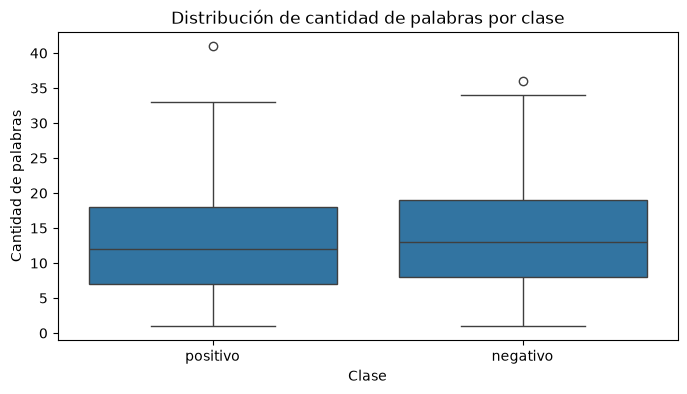

In [10]:
df_muestra = df_eda.sample(
    n=min(100000, len(df_eda)),
    random_state=42
)

plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df_muestra,
    x="clase",
    y="cantidad_palabras"
)

plt.title("Distribución de cantidad de palabras por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de palabras")
plt.show()

### Análisis de longitud e intensidad por clase

La longitud de los tweets es bastante similar entre positivos y negativos. Los tweets negativos tienen, en promedio, una cantidad de palabras apenas mayor, aunque ambas distribuciones se superponen ampliamente.

También se observa que los tweets positivos presentan, en promedio, más menciones, URLs y signos de exclamación. Además, muestran un uso levemente mayor de mayúsculas.

De todas formas, las diferencias no son lo suficientemente grandes como para distinguir el sentimiento únicamente a partir de estas características. Por eso, más adelante será necesario analizar el contenido de las palabras mediante técnicas de procesamiento de lenguaje natural.

In [11]:
# Análisis temporal

fecha_sin_zona = df_eda["date"].str.replace(
    r"\s+[A-Z]{3}\s+",
    " ",
    regex=True
)

df_eda["fecha_dt"] = pd.to_datetime(
    fecha_sin_zona,
    format="%a %b %d %H:%M:%S %Y",
    errors="coerce"
)

df_eda["hora"] = df_eda["fecha_dt"].dt.hour
df_eda["dia_mes"] = df_eda["fecha_dt"].dt.day

df_eda["dia_semana"] = (
    df_eda["fecha_dt"]
    .dt.dayofweek
    .map({
        0: "lunes",
        1: "martes",
        2: "miércoles",
        3: "jueves",
        4: "viernes",
        5: "sábado",
        6: "domingo"
    })
)

In [12]:
# Clasificar la hora del tweet en una franja horaria
def clasificar_franja_horaria(hora):
    if pd.isna(hora):
        return "sin dato"
    if 0 <= hora <= 5:
        return "madrugada"
    if 6 <= hora <= 11:
        return "matutino"
    if 12 <= hora <= 17:
        return "vespertino"
    return "nocturno"


# Clasificar el día según el momento del mes
def clasificar_momento_mes(dia):
    if pd.isna(dia):
        return "sin dato"
    if dia <= 10:
        return "principio de mes"
    if dia <= 20:
        return "mitad de mes"
    return "fin de mes"


df_eda["franja_horaria"] = (
    df_eda["hora"].apply(clasificar_franja_horaria)
)

df_eda["momento_mes"] = (
    df_eda["dia_mes"].apply(clasificar_momento_mes)
)
display(
    df_eda[[
        "date",
        "fecha_dt",
        "hora",
        "dia_semana",
        "franja_horaria",
        "momento_mes"
    ]].head(10)
)

,date,fecha_dt,hora,dia_semana,franja_horaria,momento_mes
0,Mon Apr 06 22:19:45 PDT 2009,2009-04-06 22:19:45,22,lunes,nocturno,principio de mes
1,Mon Apr 06 22:19:49 PDT 2009,2009-04-06 22:19:49,22,lunes,nocturno,principio de mes
2,Mon Apr 06 22:19:53 PDT 2009,2009-04-06 22:19:53,22,lunes,nocturno,principio de mes
3,Mon Apr 06 22:19:57 PDT 2009,2009-04-06 22:19:57,22,lunes,nocturno,principio de mes
4,Mon Apr 06 22:19:57 PDT 2009,2009-04-06 22:19:57,22,lunes,nocturno,principio de mes
5,Mon Apr 06 22:20:00 PDT 2009,2009-04-06 22:20:00,22,lunes,nocturno,principio de mes
6,Mon Apr 06 22:20:03 PDT 2009,2009-04-06 22:20:03,22,lunes,nocturno,principio de mes
7,Mon Apr 06 22:20:03 PDT 2009,2009-04-06 22:20:03,22,lunes,nocturno,principio de mes
8,Mon Apr 06 22:20:05 PDT 2009,2009-04-06 22:20:05,22,lunes,nocturno,principio de mes
9,Mon Apr 06 22:20:09 PDT 2009,2009-04-06 22:20:09,22,lunes,nocturno,principio de mes


### Variables temporales

A partir de la columna `date`, se convirtió la fecha original a un formato de fecha y hora para poder analizar cuándo fue publicado cada tweet.

Luego se crearon nuevas variables:

- `hora`: hora de publicación.
- `dia_semana`: día de la semana.
- `franja_horaria`: madrugada, matutino, vespertino o nocturno.
- `momento_mes`: principio, mitad o fin de mes.

Estas variables permiten analizar si la proporción de tweets positivos y negativos cambia según el momento de publicación.

In [13]:
# Función para calcular porcentajes por categoría
def tabla_porcentaje(variable):
    tabla = pd.crosstab(
        df_eda[variable],
        df_eda["clase"],
        normalize="index"
    ).mul(100).round(2)

    return tabla


print("Distribución porcentual por franja horaria:")
display(tabla_porcentaje("franja_horaria"))

print("Distribución porcentual por momento del mes:")
display(tabla_porcentaje("momento_mes"))

print("Distribución porcentual por día de la semana:")
display(tabla_porcentaje("dia_semana"))

Distribución porcentual por franja horaria:


clase,negativo,positivo
franja_horaria,,
madrugada,43.60,56.40
matutino,51.61,48.39
nocturno,51.27,48.73
vespertino,55.52,44.48


Distribución porcentual por momento del mes:


clase,negativo,positivo
momento_mes,,
fin de mes,48.86,51.14
mitad de mes,62.47,37.53
principio de mes,40.03,59.97


Distribución porcentual por día de la semana:


clase,negativo,positivo
dia_semana,,
domingo,42.18,57.82
jueves,75.59,24.41
lunes,42.69,57.31
martes,54.37,45.63
miércoles,70.75,29.25
sábado,47.64,52.36
viernes,50.79,49.21


In [14]:
muestra_negativos = (
    df_eda[df_eda["clase"] == "negativo"]
    [["text", "clase"]]
    .sample(n=10, random_state=42)
)

muestra_positivos = (
    df_eda[df_eda["clase"] == "positivo"]
    [["text", "clase"]]
    .sample(n=10, random_state=42)
)

display(muestra_negativos)
display(muestra_positivos)

,text,clase
776868,"Okay, that last tweet (or two) had really bad timing and I feel bad now.",negativo
541410,"4-3 Yankees. Thanks Cano! Top of the eighth, CC is still in, Jeter has been taken out of the game",negativo
78645,just found out im moving to moreno valley california! should i be worried?,negativo
176960,looks like it got cloudy again outside! and i have nothing to do tonight! boo friday,negativo
270060,I hate Monday,negativo
147772,I am at work,negativo
77938,"@NileyLover09 Thanks but I spend the day with her everyday because she lives with me lol,,,but she ripped my JB poster today",negativo
383078,Why good morning sun ... I didn't want to be awake to see you rise ! Fuckk its 430 still no sleep,negativo
366441,@Sueitsme because i hate my parents,negativo
459326,Does anybody have the May 2009 FRENCH VOGUE? I just found out I'm in it and it's too late to find it in newsstands,negativo


,text,clase
1324228,where the fuck is the sun gone to??? wanted to go swimming today... already prepared my sketchbook...,positivo
1535589,"Lol at Frank, yes please at Derren, love at Pete and yay at the sun.",positivo
1460550,@VERSUS5BEATS How loud....I can't hear anything...,positivo
1120114,"@warrenellis well, I might be persuaded....I think I've tolerated much more than that from you at this point.",positivo
1456895,happy at home. playing saxophone in the garden,positivo
1358843,@barbsrad ah jim Jim did my first one! Hes awesome!,positivo
960209,@officialnjonas http://twitpic.com/5cuih - nice pic is nice that you are in south america now,positivo
1370407,Off to see the Offspring tonight!,positivo
1525590,@ashleytisdale...yeah lets sounds like a good ideaaa,positivo
1109444,@Darienlake Please say hi to mitchel for me!!! Tell him Austin C. says hi from Mitchel Musso.com,positivo


### Revisión de las etiquetas

Al revisar una muestra de tweets positivos y negativos, se observó que la mayoría de las etiquetas coincide con el contenido. Sin embargo, también aparecen algunos casos ambiguos, neutrales o aparentemente mal etiquetados.

Por ejemplo, algunos tweets marcados como positivos expresan quejas o frustración, mientras que ciertos tweets negativos combinan expresiones positivas y negativas.

Estos casos se mantuvieron con su etiqueta original, ya que corregirlos manualmente no sería viable para todo el dataset. De todas formas, muestran que existe cierto nivel de ruido en las etiquetas y que el sentimiento de algunos tweets no siempre es completamente claro.

### Análisis temporal

A partir de las variables temporales creadas, se analiza cómo se distribuyen los tweets positivos y negativos según la franja horaria, el día de la semana y el momento del mes.

Dentro del dataset, se observa una mayor proporción de tweets positivos durante la madrugada y al principio del mes. En cambio, la franja vespertina, la mitad del mes y días como miércoles y jueves presentan una proporción mayor de tweets negativos.

Estos resultados describen únicamente el comportamiento dentro del dataset y deben interpretarse con cautela, ya que la recolección de tweets no fue uniforme a lo largo del tiempo. Por lo tanto, no se puede afirmar que esos patrones representen el comportamiento general de los usuarios de Twitter.

### Presencia de elementos según el sentimiento

Además de comparar los valores promedio, se calculó qué porcentaje de tweets de cada clase contiene hashtags, menciones, URLs, signos de exclamación o preguntas.

Este análisis permite observar si ciertos recursos propios de Twitter aparecen con mayor frecuencia en tweets positivos o negativos.

In [15]:
presencia_elementos = pd.DataFrame({
    "con_hashtag_%": (
        df_eda.groupby("clase")["cantidad_hashtags"]
        .apply(lambda x: (x > 0).mean() * 100)
    ),
    "con_mencion_%": (
        df_eda.groupby("clase")["cantidad_menciones"]
        .apply(lambda x: (x > 0).mean() * 100)
    ),
    "con_url_%": (
        df_eda.groupby("clase")["tiene_url"].mean() * 100
    ),
    "con_exclamacion_%": (
        df_eda.groupby("clase")["cantidad_exclamaciones"]
        .apply(lambda x: (x > 0).mean() * 100)
    ),
    "con_pregunta_%": (
        df_eda.groupby("clase")["cantidad_preguntas"]
        .apply(lambda x: (x > 0).mean() * 100)
    )
}).round(2)

display(presencia_elementos)

,con_hashtag_%,con_mencion_%,con_url_%,con_exclamacion_%,con_pregunta_%
clase,,,,,
negativo,1.91,37.66,3.19,24.81,10.17
positivo,2.58,54.81,6.40,35.42,10.78


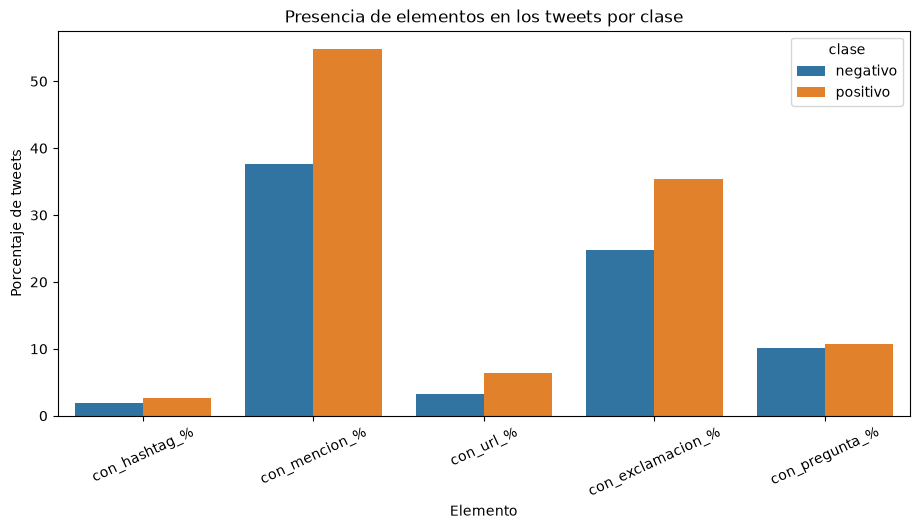

In [16]:
presencia_grafico = (
    presencia_elementos
    .reset_index()
    .melt(
        id_vars="clase",
        var_name="elemento",
        value_name="porcentaje"
    )
)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=presencia_grafico,
    x="elemento",
    y="porcentaje",
    hue="clase"
)

plt.title("Presencia de elementos en los tweets por clase")
plt.xlabel("Elemento")
plt.ylabel("Porcentaje de tweets")
plt.xticks(rotation=25)
plt.show()

### Presencia de elementos en los tweets según la clase

Al comparar la presencia de distintos elementos en los tweets, se observa que los positivos presentan porcentajes más altos en todos los casos analizados.

La diferencia más marcada aparece en las **menciones**, ya que los tweets positivos mencionan a otros usuarios con mucha más frecuencia que los negativos. También se observa una mayor presencia de **signos de exclamación** y **URLs** en los tweets positivos.

En cambio, los **hashtags** y los **signos de pregunta** muestran diferencias más pequeñas entre ambas clases.

En conjunto, estos resultados sugieren que los tweets positivos tienden a ser más interactivos y expresivos. Sin embargo, estas variables por sí solas no alcanzan para clasificar correctamente el sentimiento, por lo que el análisis principal se centrará en el contenido textual de los tweets.

## Preprocesamiento del texto

Antes de transformar los tweets mediante TF-IDF, se aplicó una limpieza para reducir ruido y unificar el formato de los textos.

In [17]:
def limpiar_tweet(texto):
    texto = str(texto).lower()
    texto = html.unescape(texto)

    texto = re.sub(r"https?://\S+|www\.\S+", " url ", texto)
    texto = re.sub(r"@\w+", " user ", texto)

    texto = re.sub(r"!+", " exclamacion ", texto)
    texto = re.sub(r"\?+", " pregunta ", texto)

    texto = re.sub(r"#", "", texto)
    texto = texto.replace("'", "")

    texto = re.sub(r"[^a-z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

df_modelo = df_limpio.copy()

df_modelo["text_clean"] = (
    df_modelo["text"]
    .apply(limpiar_tweet)
)
muestra_limpieza = (
    df_modelo[["text", "text_clean"]]
    .sample(n=10, random_state=42)
)

display(muestra_limpieza)

,text,text_clean
1235490,Calling all crafty bugs http://bit.ly/NKCDt,calling all crafty bugs url
202162,.@architeuth1s she's gone man!!! GONE!!!!,user shes gone man exclamacion gone exclamacion
1020561,@davejmatthews good morning! Coffee? Yes have some.,user good morning exclamacion coffee pregunta yes have some
624188,"media test today arrghhh. i wont be on a computer until after school, so no twitter updates",media test today arrghhh i wont be on a computer until after school so no twitter updates
762367,mosquitoes eating my alive! while indoors! this sucks. and still no word on job,mosquitoes eating my alive exclamacion while indoors exclamacion this sucks and still no word on job
14773,Its finished now i cried. Brillant movie,its finished now i cried brillant movie
1257359,@claymuse Oh man I LOVE good eats! fulfills my need for trivia AND good cooking,user oh man i love good eats exclamacion fulfills my need for trivia and good cooking
664792,"At home, pretty worried. It sucks to not have a car",at home pretty worried it sucks to not have a car
732775,@iRachey poor rai,user poor rai
713487,going to bed paris 2moz will be my last tweet for a week,going to bed paris moz will be my last tweet for a week


## Preprocesamiento de los tweets


El preprocesamiento incluye:

- conversión del texto a minúsculas;
- conversión de entidades HTML;
- reemplazo de URLs por el token `url`;
- reemplazo de menciones por el token `user`;
- conservación del contenido de los hashtags, eliminando solamente el símbolo `#`;
- reemplazo de signos de exclamación por el token `exclamacion`;
- reemplazo de signos de pregunta por el token `pregunta`;
- eliminación de otros caracteres especiales;
- normalización de espacios.

Las URLs y menciones no se eliminan por completo, sino que se reemplazan por términos genéricos. De esta manera, el modelo puede reconocer que el tweet contenía un enlace o una mención, sin considerar el valor específico.

También se decidió conservar la información de los signos de exclamación y pregunta. Estos signos pueden aportar información sobre el tono del mensaje, ya que suelen estar relacionados con intensidad, entusiasmo, sorpresa, enojo o duda.

Como TF-IDF trabaja principalmente con palabras, los signos se transforman en tokens de texto. Por ejemplo:

`I love this!!!`

se transforma en:

`i love this exclamacion`

De esta forma, TF-IDF puede utilizar la presencia de estos elementos como parte de la representación del tweet.

El objetivo de esta limpieza no es eliminar toda la información original, sino reducir elementos poco útiles y conservar aquellos que puedan aportar al análisis del sentimiento.

## Variable objetivo

La columna `sentiment` utiliza los valores originales:

- `0`: sentimiento negativo.
- `4`: sentimiento positivo.

Para trabajar con una clasificación binaria, se crea la variable `target`:

- `0`: negativo.
- `1`: positivo.

In [18]:
df_modelo["target"] = df_modelo["sentiment"].map({
    0: 0,
    4: 1
})

display(
    df_modelo[[
        "sentiment",
        "target",
        "text_clean"
    ]].head()
)

,sentiment,target,text_clean
0,0,0,user url awww thats a bummer you shoulda got david carr of third day to do it d
1,0,0,is upset that he cant update his facebook by texting it and might cry as a result school today also blah exclamacion
2,0,0,user i dived many times for the ball managed to save the rest go out of bounds
3,0,0,my whole body feels itchy and like its on fire
4,0,0,user no its not behaving at all im mad why am i here pregunta because i cant see you all over there


In [19]:
X = df_modelo["text_clean"]
y = df_modelo["target"]

print("Cantidad total de ejemplos:", len(X))

print("\nDistribución porcentual:")
print(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Cantidad total de ejemplos: 1593105

Distribución porcentual:
target
1    50.02
0    49.98
Name: proportion, dtype: float64


## División de los datos

El dataset se divide en dos conjuntos:

- 80 % para entrenamiento;
- 20 % para prueba.

Se utiliza una división estratificada para conservar aproximadamente la misma proporción de tweets positivos y negativos en ambos conjuntos.

El conjunto de prueba se mantiene separado y se utiliza solamente para evaluar el modelo con ejemplos que no fueron usados durante el entrenamiento.

In [20]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Tweets de entrenamiento:", len(X_train))
print("Tweets de prueba:", len(X_test))

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True).round(4))

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True).round(4))

Tweets de entrenamiento: 1274484
Tweets de prueba: 318621

Distribución en entrenamiento:
target
1    0.5002
0    0.4998
Name: proportion, dtype: float64

Distribución en prueba:
target
1    0.5002
0    0.4998
Name: proportion, dtype: float64


## Representación de los tweets mediante TF-IDF

Para convertir a vectores el texto y que el modelo de regresion se pueda entrenar correctamente, se utiliza TF-IDF, una técnica que asigna un peso a cada término según:

- su frecuencia dentro de un tweet;
- su importancia respecto del resto del dataset.

También se incluyen unigramas y bigramas. Los unigramas representan palabras individuales, mientras que los bigramas permiten conservar combinaciones como `not good`, `very happy` o `dont like`.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True,
    dtype=np.float32
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Matriz de entrenamiento:", X_train_tfidf.shape)
print("Matriz de prueba:", X_test_tfidf.shape)

Matriz de entrenamiento: (1274484, 50000)
Matriz de prueba: (318621, 50000)


Cada fila de las matrices representa un tweet y cada columna representa uno de los términos seleccionados por TF-IDF.

La matriz de entrenamiento contiene todos los tweets utilizados para que el modelo aprenda, mientras que la matriz de prueba contiene los tweets reservados para evaluar su rendimiento.

Se configuró un vocabulario máximo de 50.000 términos para conservar una cantidad amplia de palabras y expresiones potencialmente útiles, sin permitir que la matriz crezca de forma ilimitada.

También se utilizaron unigramas y bigramas:

- los unigramas representan palabras individuales, como `good` o `sad`;
- los bigramas representan combinaciones de dos palabras, como `not good` o `very happy`.

Los parámetros utilizados fueron:

- `max_features=50000`: limita el vocabulario a 50.000 términos;
- `min_df=5`: descarta términos que aparecen en menos de cinco tweets;
- `max_df=0.95`: descarta términos presentes en más del 95 % de los tweets;
- `ngram_range=(1, 2)`: incluye palabras individuales y pares de palabras;
- `sublinear_tf=True`: reduce el impacto de las repeticiones excesivas de un mismo término;
- `dtype=np.float32`: disminuye el consumo de memoria.

TF-IDF se ajustó solamente con el conjunto de entrenamiento. Luego, el conjunto de prueba se transformó utilizando el mismo vocabulario, evitando así la fuga de información.

## Entrenamiento del modelo

Para clasificar los tweets se utilizó Regresión Logística.

Este modelo suele funcionar bien con representaciones TF-IDF, ya que puede trabajar eficientemente con una gran cantidad de variables dispersas.

Durante el entrenamiento, el modelo aprende un peso para cada término. Los términos asociados con expresiones positivas empujan la predicción hacia la clase positiva, mientras que los términos asociados con expresiones negativas la orientan hacia la clase negativa.

In [22]:
import time

from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(
    max_iter=1000,
    solver="saga",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

inicio = time.time()

modelo_lr.fit(
    X_train_tfidf,
    y_train
)

tiempo_entrenamiento = time.time() - inicio

print(
    f"Tiempo de entrenamiento: "
    f"{tiempo_entrenamiento:.2f} segundos"
)

/home/matias/clases-diplomatura/tp3-nlp-tweets/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Tiempo de entrenamiento: 634.20 segundos


/home/matias/clases-diplomatura/tp3-nlp-tweets/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


La Regresión Logística se configuró con un máximo de 1.000 iteraciones para darle suficiente margen para converger.

Se utilizó el solver `saga`, adecuado para datasets grandes y matrices dispersas como las generadas por TF-IDF.

También se mantuvo una semilla fija para que los resultados puedan reproducirse.

In [23]:
inicio = time.time()

y_pred = modelo_lr.predict(X_test_tfidf)

tiempo_prediccion = time.time() - inicio

print(
    f"Tiempo de predicción: "
    f"{tiempo_prediccion:.2f} segundos"
)

Tiempo de predicción: 0.01 segundos


Las predicciones se realizaron sobre el conjunto de prueba, que contiene tweets que no fueron utilizados durante el entrenamiento.

Esto permite estimar cómo funcionaría el modelo frente a textos nuevos.

## Evaluación del modelo

El rendimiento se evaluó mediante distintas métricas:

- **Accuracy:** porcentaje total de predicciones correctas.
- **Precision:** de todos los tweets predichos como positivos, cuántos eran realmente positivos.
- **Recall:** de todos los tweets positivos reales, cuántos fueron identificados correctamente.
- **F1-score:** combina precision y recall en una sola medida.
- **F1 macro:** calcula el F1 de cada clase y luego obtiene su promedio, dando la misma importancia a tweets positivos y negativos.

Se incluye el F1 macro para evaluar el rendimiento de manera equilibrada sobre ambas clases.

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

metricas_modelo = pd.DataFrame([{
    "modelo": "TF-IDF + Regresión Logística",
    "accuracy": accuracy_score(y_test, y_pred),
    "f1_positivo": f1_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "f1_macro": f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    ),
    "tiempo_entrenamiento_seg": tiempo_entrenamiento,
    "tiempo_prediccion_seg": tiempo_prediccion
}])

display(metricas_modelo.round(4))

,modelo,accuracy,f1_positivo,f1_macro,tiempo_entrenamiento_seg,tiempo_prediccion_seg
0,TF-IDF + Regresión Logística,0.8237,0.8258,0.8237,634.2047,0.0055


El modelo obtuvo un accuracy y un F1 macro de **82,4%**.

El reporte de clasificación permite observar el rendimiento individual sobre tweets negativos y positivos. Los valores de precision, recall y F1 fueron **iguales** entre ambas clases.

Esto indica que el modelo **mantiene un comportamiento equilibrado**.

### Matriz de confusión

La matriz de confusión permite observar cuántos tweets fueron clasificados correctamente y qué tipo de errores cometió el modelo.

La diagonal principal representa los aciertos:

- tweets negativos clasificados como negativos;
- tweets positivos clasificados como positivos.

Los valores restantes representan los errores:

- tweets negativos clasificados como positivos;
- tweets positivos clasificados como negativos.

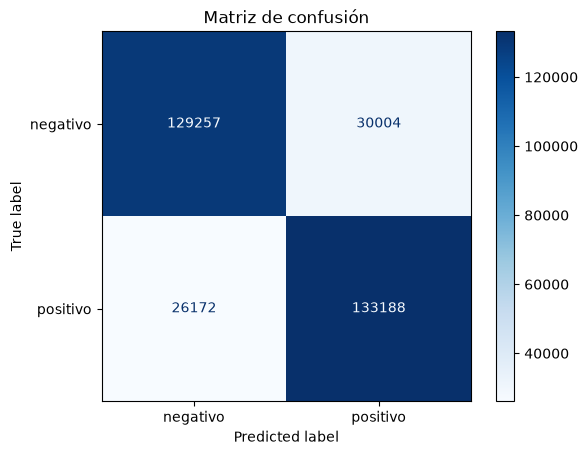

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["negativo", "positivo"],
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusión")
plt.show()

In [26]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

print("Negativos correctamente clasificados:", tn)
print("Negativos clasificados como positivos:", fp)
print("Positivos clasificados como negativos:", fn)
print("Positivos correctamente clasificados:", tp)

Negativos correctamente clasificados: 129257
Negativos clasificados como positivos: 30004
Positivos clasificados como negativos: 26172
Positivos correctamente clasificados: 133188


La matriz de confusión muestra que el modelo clasificó correctamente **129257** tweets negativos y **133188** tweets positivos.

Los errores corresponden a **26172** tweets negativos clasificados como positivos y **30004** tweets positivos clasificados como negativos.

## Comparación entre entrenamiento y prueba

Para revisar si el modelo presenta sobreajuste, se compara su rendimiento sobre el conjunto de entrenamiento y el conjunto de prueba.

El sobreajuste ocurre cuando un modelo obtiene resultados muy altos sobre los datos utilizados para entrenarlo, pero pierde mucho rendimiento frente a datos nuevos.

Una diferencia reducida entre entrenamiento y prueba sugiere una mejor capacidad de generalización.

In [27]:
pred_train = modelo_lr.predict(X_train_tfidf)

resultados_train_test = pd.DataFrame([
    {
        "conjunto": "entrenamiento",
        "accuracy": accuracy_score(
            y_train,
            pred_train
        ),
        "f1_macro": f1_score(
            y_train,
            pred_train,
            average="macro",
            zero_division=0
        )
    },
    {
        "conjunto": "prueba",
        "accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "f1_macro": f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        )
    }
])

display(resultados_train_test.round(4))

,conjunto,accuracy,f1_macro
0,entrenamiento,0.8362,0.8362
1,prueba,0.8237,0.8237


In [28]:
f1_train = resultados_train_test.loc[
    resultados_train_test["conjunto"] == "entrenamiento",
    "f1_macro"
].iloc[0]

f1_test = resultados_train_test.loc[
    resultados_train_test["conjunto"] == "prueba",
    "f1_macro"
].iloc[0]

diferencia_f1 = f1_train - f1_test

print(
    "Diferencia de F1 macro entre entrenamiento y prueba:",
    round(diferencia_f1, 4)
)

Diferencia de F1 macro entre entrenamiento y prueba: 0.0125


El F1 macro de entrenamiento fue de **83.6%**, mientras que en prueba fue de **82.3**.

La diferencia entre ambos conjuntos fue de **1.25%**.

Como la diferencia es **pequeña**, el modelo **no muestra señales importantes de overfitting**.

## Segundo modelo: Random Forest

La consigna pide entrenar y evaluar como mínimo dos modelos con algoritmos vistos en clase. Se entrena un segundo modelo, Random Forest, sobre la misma representación TF-IDF utilizada para la Regresión Logística.

Random Forest fue uno de los algoritmos de clasificación vistos en el curso (Módulo 2, Bagging & Boosting), por lo que se eligió como segundo modelo para esta comparación.

In [29]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=40,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

inicio = time.time()

modelo_rf.fit(
    X_train_tfidf,
    y_train
)

tiempo_entrenamiento_rf = time.time() - inicio

print(
    f"Tiempo de entrenamiento: "
    f"{tiempo_entrenamiento_rf:.2f} segundos"
)

Tiempo de entrenamiento: 171.74 segundos


Se configuraron 200 árboles (`n_estimators=200`) para estabilizar el promedio de las predicciones, y una profundidad máxima de 40 (`max_depth=40`) para acotar el tiempo de entrenamiento sobre una matriz TF-IDF de gran dimensión, evitando árboles excesivamente profundos y propensos al sobreajuste.

Se mantiene la misma semilla (`RANDOM_STATE`) que en la Regresión Logística para que los resultados sean reproducibles.

In [30]:
inicio = time.time()

y_pred_rf = modelo_rf.predict(X_test_tfidf)

tiempo_prediccion_rf = time.time() - inicio

print(
    f"Tiempo de predicción: "
    f"{tiempo_prediccion_rf:.2f} segundos"
)

Tiempo de predicción: 0.48 segundos


### Evaluación del Random Forest

In [31]:
metricas_rf = pd.DataFrame([{
    "modelo": "TF-IDF + Random Forest",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "f1_positivo": f1_score(
        y_test,
        y_pred_rf,
        zero_division=0
    ),
    "f1_macro": f1_score(
        y_test,
        y_pred_rf,
        average="macro",
        zero_division=0
    ),
    "tiempo_entrenamiento_seg": tiempo_entrenamiento_rf,
    "tiempo_prediccion_seg": tiempo_prediccion_rf
}])

metricas_modelo = pd.concat(
    [metricas_modelo, metricas_rf],
    ignore_index=True
)

display(metricas_modelo.round(4))

,modelo,accuracy,f1_positivo,f1_macro,tiempo_entrenamiento_seg,tiempo_prediccion_seg
0,TF-IDF + Regresión Logística,0.8237,0.8258,0.8237,634.2047,0.0055
1,TF-IDF + Random Forest,0.7583,0.7583,0.7583,171.7367,0.4810


In [32]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["negativo", "positivo"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negativo       0.76      0.76      0.76    159261
    positivo       0.76      0.76      0.76    159360

    accuracy                           0.76    318621
   macro avg       0.76      0.76      0.76    318621
weighted avg       0.76      0.76      0.76    318621



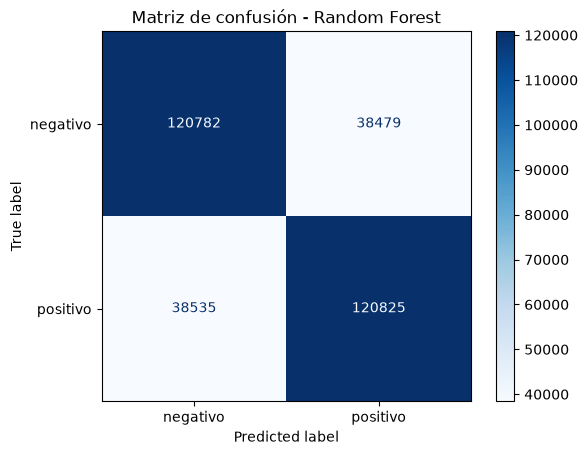

In [33]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["negativo", "positivo"],
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusión - Random Forest")
plt.show()

### Comparación entre entrenamiento y prueba (Random Forest)

Igual que con la Regresión Logística, se compara el rendimiento del Random Forest entre entrenamiento y prueba para revisar señales de sobreajuste.

In [34]:
pred_train_rf = modelo_rf.predict(X_train_tfidf)

resultados_train_test_rf = pd.DataFrame([
    {
        "conjunto": "entrenamiento",
        "accuracy": accuracy_score(
            y_train,
            pred_train_rf
        ),
        "f1_macro": f1_score(
            y_train,
            pred_train_rf,
            average="macro",
            zero_division=0
        )
    },
    {
        "conjunto": "prueba",
        "accuracy": accuracy_score(
            y_test,
            y_pred_rf
        ),
        "f1_macro": f1_score(
            y_test,
            y_pred_rf,
            average="macro",
            zero_division=0
        )
    }
])

display(resultados_train_test_rf.round(4))

,conjunto,accuracy,f1_macro
0,entrenamiento,0.7775,0.7775
1,prueba,0.7583,0.7583


In [35]:
f1_train_rf = resultados_train_test_rf.loc[
    resultados_train_test_rf["conjunto"] == "entrenamiento",
    "f1_macro"
].iloc[0]

f1_test_rf = resultados_train_test_rf.loc[
    resultados_train_test_rf["conjunto"] == "prueba",
    "f1_macro"
].iloc[0]

diferencia_f1_rf = f1_train_rf - f1_test_rf

print(
    "Diferencia de F1 macro entre entrenamiento y prueba:",
    round(diferencia_f1_rf, 4)
)

Diferencia de F1 macro entre entrenamiento y prueba: 0.0192


El Random Forest obtuvo un accuracy y F1 macro de **75.8%**, por debajo del **82.4%** de la Regresión Logística. El F1 macro en entrenamiento fue de **77.75%**, con una diferencia de solo **1.92 puntos porcentuales** respecto a prueba, por lo que tampoco muestra señales importantes de sobreajuste.

El entrenamiento del Random Forest fue bastante más rápido que el de la Regresión Logística: **171.7 segundos**, frente a los **634.2 segundos** que tardó la Regresión Logística con el solver `saga`.

Este resultado es consistente con lo esperado para texto representado con TF-IDF de alta dimensión: los modelos lineales como la Regresión Logística suelen aprovechar mejor esa dispersión, ya que cada término aporta directamente a la predicción con un peso propio, mientras que Random Forest, al particionar el espacio en base a umbrales sobre features individuales, pierde eficacia cuando hay muchísimas variables dispersas y poco correlacionadas entre sí.

Dado que la Regresión Logística obtuvo mejor performance, es el modelo que se usa como referencia principal en las secciones siguientes (interpretación de términos, análisis de errores y comparación con TextBlob).

## Interpretación de los términos aprendidos

La Regresión Logística asigna un coeficiente a cada término del vocabulario TF-IDF.

Los coeficientes positivos más altos corresponden a palabras o expresiones que aumentan la probabilidad de clasificar un tweet como positivo.

Los coeficientes negativos corresponden a términos que orientan la clasificación hacia la clase negativa.

In [36]:
terminos = tfidf.get_feature_names_out()
coeficientes = modelo_lr.coef_[0]

cantidad_terminos = 25

indices_positivos = np.argsort(
    coeficientes
)[-cantidad_terminos:][::-1]

indices_negativos = np.argsort(
    coeficientes
)[:cantidad_terminos]

terminos_importantes = pd.DataFrame({
    "terminos_positivos": terminos[indices_positivos],
    "peso_positivo": coeficientes[indices_positivos],
    "terminos_negativos": terminos[indices_negativos],
    "peso_negativo": coeficientes[indices_negativos]
})

display(terminos_importantes.round(4))

,terminos_positivos,peso_positivo,terminos_negativos,peso_negativo
0,cant wait,10.8711,sad,-16.063499
1,not bad,8.2190,miss,-10.709100
2,no problem,8.2031,poor,-10.051700
3,thanks,6.3628,cant,-9.621200
4,happy,6.2373,sick,-9.525500
5,welcome,5.9778,sadly,-9.167200
6,cannot wait,5.9552,missing,-9.002600
7,no need,5.9448,not happy,-8.715200
8,excited,5.8416,not looking,-8.414800
9,smile,5.7657,unfortunately,-8.392400


Entre los términos más asociados con la clase positiva aparecen expresiones relacionadas con **cant wait**.

En los tweets negativos se destacan términos vinculados con **sad**.

La presencia de bigramas también permite que el modelo reconozca expresiones completas, como negaciones o combinaciones de palabras que no podrían interpretarse correctamente observando cada término por separado.

Este análisis muestra que el modelo aprendió patrones coherentes con el objetivo de clasificación.

In [37]:
tokens_especiales = [
    "exclamacion",
    "pregunta",
    "user",
    "url"
]

filas_tokens = []

for token in tokens_especiales:
    if token in tfidf.vocabulary_:
        indice = tfidf.vocabulary_[token]

        filas_tokens.append({
            "token": token,
            "coeficiente": coeficientes[indice],
            "interpretacion": (
                "más asociado a positivo"
                if coeficientes[indice] > 0
                else "más asociado a negativo"
            )
        })

tokens_resultado = pd.DataFrame(filas_tokens)

display(tokens_resultado.round(4))

,token,coeficiente,interpretacion
0,exclamacion,3.6988,más asociado a positivo
1,pregunta,0.5655,más asociado a positivo
2,user,0.1406,más asociado a positivo
3,url,2.0821,más asociado a positivo


### Influencia de los elementos conservados durante la limpieza

Durante el preprocesamiento, las menciones, URLs, exclamaciones y preguntas fueron reemplazadas por tokens textuales.

Esto permitió que TF-IDF y la Regresión Logística aprendieran si la presencia de estos elementos estaba más asociada con tweets positivos o negativos.

Los coeficientes obtenidos muestran que los cuatro elementos están más asociados con la clase positiva. La mayor influencia corresponde al token `exclamacion`, seguido por `url`, mientras que `pregunta` y `user` presentan una asociación positiva más leve.

Este resultado complementa el análisis exploratorio, donde se había observado que algunos de estos elementos tenían una frecuencia diferente según la clase.

## Análisis de errores

In [38]:
resultados_prediccion = pd.DataFrame({
    "texto_original": df_modelo.loc[
        X_test.index,
        "text"
    ],
    "texto_limpio": X_test,
    "clase_real": y_test,
    "clase_predicha": y_pred
})

resultados_prediccion["clase_real"] = (
    resultados_prediccion["clase_real"]
    .map({
        0: "negativo",
        1: "positivo"
    })
)

resultados_prediccion["clase_predicha"] = (
    resultados_prediccion["clase_predicha"]
    .map({
        0: "negativo",
        1: "positivo"
    })
)
falsos_positivos = resultados_prediccion[
    (resultados_prediccion["clase_real"] == "negativo")
    &
    (resultados_prediccion["clase_predicha"] == "positivo")
]

print("Cantidad de falsos positivos:", len(falsos_positivos))

display(
    falsos_positivos[
        [
            "texto_original",
            "clase_real",
            "clase_predicha"
        ]
    ].sample(
        n=min(10, len(falsos_positivos)),
        random_state=42
    )
)
falsos_negativos = resultados_prediccion[
    (resultados_prediccion["clase_real"] == "positivo")
    &
    (resultados_prediccion["clase_predicha"] == "negativo")
]

print("Cantidad de falsos negativos:", len(falsos_negativos))

display(
    falsos_negativos[
        [
            "texto_original",
            "clase_real",
            "clase_predicha"
        ]
    ].sample(
        n=min(10, len(falsos_negativos)),
        random_state=42
    )
)

Cantidad de falsos positivos: 30004


,texto_original,clase_real,clase_predicha
224177,"@kaileycost But look at the Cosmo's name...you know how funny I'd think that was if I were there. I miss Boathouse, you, &amp; @katiefuhrman",negativo,positivo
637131,&quot;I am you and you are me&quot; dice Dave Gahan en www.openradiux.com,negativo,positivo
620664,@lachance680 Lol yes it was fun...til I heard that brash Brummie accent,negativo,positivo
400628,@theodormaghrak feel better eat some soup and saltines. Do/did you present today?,negativo,positivo
502045,An even 100 followers..I might drop below the century mark,negativo,positivo
207435,Definitely need a ride any takers??,negativo,positivo
215977,@justcallmeKingy good times... I still have 6 pages of stuff to do before going to bed,negativo,positivo
549792,"i'm gonna be so busy the next couple of days. i might not be on twitter much, but i love you all so have a great week &amp; listen to LVATT!",negativo,positivo
560567,"Good afternoon everyone, not smiling today cos it raining",negativo,positivo
713450,"headed to borders for magazines, books and coffee...this is what passes for a intresting saturday night for a one legged gimp",negativo,positivo


Cantidad de falsos negativos: 26172


,texto_original,clase_real,clase_predicha
926347,Looking at some cute little bags Wishing i had money. Good times.,positivo,negativo
1402872,Saturday of English in the office...,positivo,negativo
1405219,SO tired.. but! gotta put a mile on my faceeee,positivo,negativo
1118597,--Out late last night and then continued to party by myself at home w/ Pandora. Now I'm all tired. Nap time! Tv time!,positivo,negativo
1438356,Bad desisions with free beer. Ahhhh no ..... I miss someone,positivo,negativo
1447498,"@studdastuffy hm, nothing. disappointed because Mexico lost to freaking El Salvador on soccer, wtf, but other than that, I'm ok you?",positivo,negativo
1325006,I wonder if ppl realize that there is a diff in shaking or nodding ur head...Shaking means NO...nodding means YES,positivo,negativo
1460199,"@fergusjackson Well, registered now - nothing in tc's about me being disqualified MySoti.com is going well but still hunting for work. U?",positivo,negativo
1128614,"Just got in from work. Quite a few funsies tonight I need to sleep though now, up bright and early for riding. WOHOOOOOO",positivo,negativo
1565909,is it normal to get pissed off at someone just from hearing their voice or do I have problems....?,positivo,negativo


### Análisis de errores de clasificación

Al revisar los falsos positivos y falsos negativos, se observa que muchos de los errores aparecen en tweets con sentimientos mixtos, frases ambiguas o expresiones que dependen del contexto.

Entre los falsos positivos hay tweets etiquetados como negativos que incluyen palabras o expresiones asociadas con algo positivo, como `fun`, `good times`, `love`, `feel better` o `great week`. Aunque el mensaje completo puede contener una queja, preocupación o situación negativa, esas palabras pueden llevar al modelo a clasificarlos como positivos.

En los falsos negativos ocurre lo contrario. Algunos tweets etiquetados como positivos contienen términos como `tired`, `disappointed`, `bad decisions`, `pissed off`, `nothing` o `lost`, que suelen aparecer en contextos negativos. El modelo les da bastante importancia y termina clasificando el tweet como negativo, aunque la etiqueta original sea positiva.

También aparecen casos en los que la etiqueta del dataset resulta discutible. Por ejemplo, algunos tweets marcados como positivos expresan claramente cansancio, enojo o decepción. Esto refuerza la idea de que existe cierto ruido en las etiquetas originales.

### Probabilidad del modelo sobre cada tweet

Además de la clase predicha, la Regresión Logística permite obtener la probabilidad que el modelo asigna a cada clase mediante `predict_proba`.

Este valor indica qué tan seguro está el modelo de su predicción: probabilidades cercanas al 100% corresponden a predicciones confiadas, mientras que probabilidades cercanas al 50% indican que el modelo dudó entre ambas clases.

In [39]:
probabilidades = modelo_lr.predict_proba(X_test_tfidf)

resultados_prediccion["prob_negativo"] = probabilidades[:, 0]
resultados_prediccion["prob_positivo"] = probabilidades[:, 1]

columnas_probabilidad = [
    "texto_original",
    "clase_real",
    "clase_predicha",
    "prob_negativo",
    "prob_positivo"
]

formato_porcentaje = {
    "prob_negativo": "{:.1%}",
    "prob_positivo": "{:.1%}"
}

muestra_probabilidades = (
    resultados_prediccion[columnas_probabilidad]
    .sample(
        n=10,
        random_state=42
    )
)

display(
    muestra_probabilidades
    .style.format(formato_porcentaje)
)

# Tweets donde el modelo estuvo menos seguro (probabilidades cercanas al 50%)
tweets_dudosos = (
    resultados_prediccion
    .assign(
        margen=(
            resultados_prediccion["prob_positivo"] - 0.5
        ).abs()
    )
    .sort_values("margen")
    .head(10)
)

display(
    tweets_dudosos[columnas_probabilidad]
    .style.format(formato_porcentaje)
)

,texto_original,clase_real,clase_predicha,prob_negativo,prob_positivo
352158,"Giving up the ghost on camping. Rescheduling 4 the 2nd week in July. I'm sure it'll be 90F or snow, just for me. Double",negativo,positivo,42.6%,57.4%
202617,"@Penncypoo What a gorgeous name, Meadow. I LOVE it, I suggested that to my dh, but he looked at me like I was nuts.",negativo,positivo,26.1%,73.9%
499296,@babygirlparis http://twitpic.com/7ia6v - if only once i could fly like that,negativo,negativo,53.7%,46.3%
155183,@LittrellHHC I wish I could go but it's too far to travel Do something in Cali!,negativo,negativo,97.5%,2.5%
530745,@djirie I miss you!! I'm an apple girl now,negativo,negativo,69.1%,30.9%
795479,@problematik its only available to 50 states.....,negativo,negativo,73.2%,26.8%
514713,Odessa can't have surgery cause something else is wrong with her,negativo,negativo,97.7%,2.3%
4547,"Kelly Good morning fellow tweets, there is allot of spamers on here. but thats ok, I'll just get rid of them. http://ff.im/1Y9yn",negativo,positivo,15.1%,84.9%
225983,My mom robbed me,negativo,negativo,93.9%,6.1%
44436,going to go to sleep cause he has to work in the morning,negativo,negativo,84.9%,15.1%


,texto_original,clase_real,clase_predicha,prob_negativo,prob_positivo
494555,@kateluvs23 oh my heavens I looooove that spot! Man I miss LA!! http://myloc.me/3XVW,negativo,positivo,50.0%,50.0%
1108546,blog thingy just makes me smilee,positivo,negativo,50.0%,50.0%
1227911,"@hullabaloon I never give a shit, unless I need to",positivo,positivo,50.0%,50.0%
1012478,@Solario we should go and watch Antichrist! A whole lotta hate!!,positivo,negativo,50.0%,50.0%
282755,@HeartBreakV I'm at oakland univ,negativo,negativo,50.0%,50.0%
510494,"@GameHouse Kristy, i clicked on the link of downloading free Pizza Chef, then created my account & Pizza Chef disappeared",negativo,negativo,50.0%,50.0%
1134001,going to the ozarks!!! @kllybntly and i will be in 86 degree weather for a couple days,positivo,negativo,50.0%,50.0%
449592,"@travismckie omg, shut up! okay, you need to enroll me in the ""Mckie Rehabilitation Facility"" .. i wanna get better lol",negativo,negativo,50.0%,50.0%
1332732,"Some scary art "" Check me out some scary shit lol "" http://bit.ly/jyNAF",positivo,positivo,50.0%,50.0%
1495221,@OfficialSKnight OMG i was watching u on tv!!!!,positivo,negativo,50.0%,50.0%


## Similitud coseno entre tweets y centroides de clase

Como métrica adicional vista en clase (similitud coseno), se calcula qué tan cerca está cada tweet del vector promedio (centroide) de los tweets negativos y positivos del conjunto de entrenamiento, usando la representación TF-IDF.

Esto permite, por un lado, armar un clasificador simple por cercanía al centroide más similar, y por otro, revisar si los errores del modelo de Regresión Logística corresponden a tweets "ambiguos": aquellos cuya similitud es pareja hacia ambas clases.

In [40]:
from sklearn.metrics.pairwise import cosine_similarity

centroide_negativo = np.asarray(
    X_train_tfidf[(y_train == 0).values].mean(axis=0)
)
centroide_positivo = np.asarray(
    X_train_tfidf[(y_train == 1).values].mean(axis=0)
)

centroides = np.vstack([centroide_negativo, centroide_positivo])

similitud_test = cosine_similarity(X_test_tfidf, centroides)

resultados_prediccion["similitud_negativo"] = similitud_test[:, 0]
resultados_prediccion["similitud_positivo"] = similitud_test[:, 1]
resultados_prediccion["margen_similitud"] = (
    resultados_prediccion["similitud_positivo"]
    - resultados_prediccion["similitud_negativo"]
).abs()

display(
    resultados_prediccion[
        [
            "texto_original",
            "clase_real",
            "clase_predicha",
            "similitud_negativo",
            "similitud_positivo",
            "margen_similitud"
        ]
    ].head()
)

,texto_original,clase_real,clase_predicha,similitud_negativo,similitud_positivo,margen_similitud
1262112,@irmaaw tell jg my birthday wishes for him. thanks,positivo,positivo,0.072879,0.093698,0.020819
1586053,@ZanaSolo biking om! Dushi yu! Bo ta ready for the outdoors anto!,positivo,positivo,0.101232,0.137648,0.036415
278278,so another week begins &amp; i have to miss spending time with her,negativo,negativo,0.112903,0.081889,0.031014
1111227,today is the first day that my summer starts,positivo,positivo,0.114606,0.101115,0.013491
888073,Wow - we have a fair amount of bright sunshine for a predicted rainy day,positivo,negativo,0.067732,0.067086,0.000645


### Clasificación por cercanía al centroide

Como referencia adicional, se clasifica cada tweet de prueba según el centroide con el que tiene mayor similitud coseno, sin usar ningún modelo entrenado.

In [41]:
y_pred_centroide = np.where(
    resultados_prediccion["similitud_positivo"]
    > resultados_prediccion["similitud_negativo"],
    "positivo",
    "negativo"
)

accuracy_centroide = accuracy_score(
    resultados_prediccion["clase_real"],
    y_pred_centroide
)
f1_macro_centroide = f1_score(
    resultados_prediccion["clase_real"],
    y_pred_centroide,
    average="macro",
    zero_division=0
)

print(
    "Accuracy por similitud coseno al centroide:",
    round(accuracy_centroide, 4)
)
print(
    "F1 macro por similitud coseno al centroide:",
    round(f1_macro_centroide, 4)
)

Accuracy por similitud coseno al centroide: 0.7116
F1 macro por similitud coseno al centroide: 0.7111


### Margen de similitud en aciertos y errores

Se compara el margen de similitud (diferencia absoluta entre la similitud a cada centroide) entre las predicciones correctas e incorrectas de la Regresión Logística. Un margen más chico indica un tweet más ambiguo en términos de vocabulario.

In [42]:
resultados_prediccion["prediccion_correcta"] = (
    resultados_prediccion["clase_real"]
    == resultados_prediccion["clase_predicha"]
)

margen_por_acierto = (
    resultados_prediccion
    .groupby("prediccion_correcta")["margen_similitud"]
    .mean()
)

display(margen_por_acierto.round(4))

prediccion_correcta
False    0.0128
True     0.0167
Name: margen_similitud, dtype: float32

La clasificación simple por cercanía al centroide obtuvo un accuracy de **71.16%** y un F1 macro de **71.11%** — por debajo de los dos modelos entrenados, pero bastante mejor que adivinar al azar (50%). Esto confirma que la similitud coseno sobre la representación TF-IDF captura información real sobre el sentimiento del tweet, aun sin entrenar ningún clasificador.

Además, el margen de similitud (diferencia entre la similitud al centroide positivo y al negativo) fue menor en las predicciones **incorrectas** de la Regresión Logística (0.0128 en promedio) que en las **correctas** (0.0167). Esto respalda la idea de que buena parte de los errores del modelo corresponden a tweets ambiguos, cuyo vocabulario no se parece claramente a ninguna de las dos clases.

## Comparación con TextBlob

Como referencia externa, se utiliza TextBlob, una herramienta de análisis de sentimiento basada en reglas y léxicos previamente definidos.

A diferencia de la Regresión Logística, TextBlob no se entrena con los tweets de este dataset. En su lugar, asigna a cada texto una polaridad numérica:

- valores mayores a `0`: sentimiento positivo;
- valores menores a `0`: sentimiento negativo;
- valor `0`: sentimiento neutral o sin polaridad detectada.

Como este trabajo plantea una clasificación binaria, las polaridades mayores a cero se clasifican como positivas y las polaridades menores o iguales a cero se clasifican como negativas.

TextBlob funciona como un modelo de referencia generalista para comparar cuánto aporta entrenar un clasificador específicamente con los tweets del dataset.

In [43]:
X_train_original = df_modelo.loc[X_train.index, "text"].astype(str)
X_test_original = df_modelo.loc[X_test.index, "text"].astype(str)

print("Tweets de train para TextBlob:", len(X_train_original))
print("Tweets de test para TextBlob :", len(X_test_original))

def obtener_polaridad_textblob(texto):
    return TextBlob(texto).sentiment.polarity


def clasificar_textblob(polaridad):
    if polaridad > 0:
        return 1  # positivo
    return 0      # negativo

Tweets de train para TextBlob: 1274484
Tweets de test para TextBlob : 318621


In [44]:
import time

inicio_train = time.time()

polaridades_textblob_train = X_train_original.apply(
    obtener_polaridad_textblob
)
y_pred_textblob_train = polaridades_textblob_train.apply(
    clasificar_textblob
)
tiempo_textblob_train = time.time() - inicio_train

inicio_test = time.time()
polaridades_textblob_test = X_test_original.apply(
    obtener_polaridad_textblob
)
y_pred_textblob_test = polaridades_textblob_test.apply(
    clasificar_textblob
)
tiempo_textblob_test = time.time() - inicio_test

# Alias para las celdas posteriores, que muestran la evaluación final en test.
y_pred_textblob = y_pred_textblob_test
polaridades_textblob = polaridades_textblob_test
tiempo_textblob = tiempo_textblob_test

print(f"Tiempo de inferencia en train: {tiempo_textblob_train:.2f} segundos")
print(f"Tiempo de inferencia en test : {tiempo_textblob_test:.2f} segundos")
print("Polaridad cero en train:", (polaridades_textblob_train == 0).sum())
print("Polaridad cero en test :", (polaridades_textblob_test == 0).sum())

Tiempo de inferencia en train: 108.07 segundos
Tiempo de inferencia en test : 26.91 segundos
Polaridad cero en train: 452083
Polaridad cero en test : 112915


In [45]:
def calcular_metricas_textblob(conjunto, y_real, y_predicha, tiempo):
    return {
        "conjunto": conjunto,
    "accuracy": accuracy_score(
            y_real,
            y_predicha
    ),
    "precision_positivo": precision_score(
            y_real,
            y_predicha,
        zero_division=0
    ),
    "recall_positivo": recall_score(
            y_real,
            y_predicha,
        zero_division=0
    ),
    "f1_positivo": f1_score(
            y_real,
            y_predicha,
        zero_division=0
    ),
    "f1_macro": f1_score(
            y_real,
            y_predicha,
        average="macro",
        zero_division=0
    ),
        "tiempo_inferencia_seg": tiempo
    }


metricas_textblob_train_test = pd.DataFrame([
    calcular_metricas_textblob(
        "entrenamiento", y_train, y_pred_textblob_train, tiempo_textblob_train
    ),
    calcular_metricas_textblob(
        "prueba", y_test, y_pred_textblob_test, tiempo_textblob_test
    )
])

f1_textblob_train = metricas_textblob_train_test.loc[
    metricas_textblob_train_test["conjunto"] == "entrenamiento", "f1_macro"
].iloc[0]
f1_textblob_test = metricas_textblob_train_test.loc[
    metricas_textblob_train_test["conjunto"] == "prueba", "f1_macro"
].iloc[0]

display(metricas_textblob_train_test.round(4))
print("Gap F1 macro train-test:", round(f1_textblob_train - f1_textblob_test, 4))

# Fila de test usada en la comparación final con la Regresión Logística.
metricas_textblob = metricas_textblob_train_test.query(
    "conjunto == 'prueba'"
).drop(columns="conjunto").assign(
    modelo="TextBlob",
    tiempo_entrenamiento_seg=0
).rename(columns={"tiempo_inferencia_seg": "tiempo_prediccion_seg"})

metricas_textblob = metricas_textblob[
    ["modelo", "accuracy", "precision_positivo", "recall_positivo",
     "f1_positivo", "f1_macro", "tiempo_entrenamiento_seg",
     "tiempo_prediccion_seg"]
]

display(metricas_textblob.round(4))

,conjunto,accuracy,precision_positivo,recall_positivo,f1_positivo,f1_macro,tiempo_inferencia_seg
0,entrenamiento,0.6222,0.6401,0.5586,0.5966,0.6206,108.0657
1,prueba,0.6257,0.6438,0.5633,0.6009,0.6243,26.9099


Gap F1 macro train-test: -0.0036


,modelo,accuracy,precision_positivo,recall_positivo,f1_positivo,f1_macro,tiempo_entrenamiento_seg,tiempo_prediccion_seg
1,TextBlob,0.6257,0.6438,0.5633,0.6009,0.6243,0,26.9099


In [46]:
print(
    classification_report(
        y_test,
        y_pred_textblob,
        target_names=["negativo", "positivo"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negativo       0.61      0.69      0.65    159261
    positivo       0.64      0.56      0.60    159360

    accuracy                           0.63    318621
   macro avg       0.63      0.63      0.62    318621
weighted avg       0.63      0.63      0.62    318621



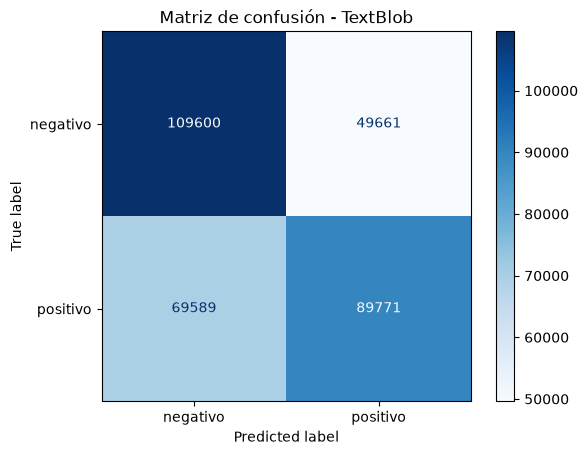

In [47]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_textblob,
    display_labels=["negativo", "positivo"],
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusión - TextBlob")
plt.show()

In [48]:
comparacion_final = pd.concat(
    [
        metricas_modelo,
        metricas_textblob
    ],
    ignore_index=True
).sort_values(
    "f1_macro",
    ascending=False
)

display(comparacion_final.round(4))

,modelo,accuracy,f1_positivo,f1_macro,tiempo_entrenamiento_seg,tiempo_prediccion_seg,precision_positivo,recall_positivo
0,TF-IDF + Regresión Logística,0.8237,0.8258,0.8237,634.2047,0.0055,NaN,NaN
1,TF-IDF + Random Forest,0.7583,0.7583,0.7583,171.7367,0.4810,NaN,NaN
2,TextBlob,0.6257,0.6009,0.6243,0.0000,26.9099,0.6438,0.5633


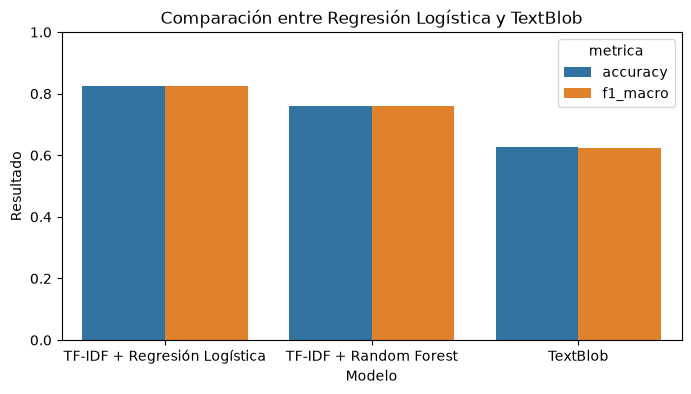

In [49]:
comparacion_grafico = (
    comparacion_final[
        ["modelo", "accuracy", "f1_macro"]
    ]
    .melt(
        id_vars="modelo",
        var_name="metrica",
        value_name="valor"
    )
)

plt.figure(figsize=(8, 4))

sns.barplot(
    data=comparacion_grafico,
    x="modelo",
    y="valor",
    hue="metrica"
)

plt.title("Comparación entre Regresión Logística y TextBlob")
plt.xlabel("Modelo")
plt.ylabel("Resultado")
plt.ylim(0, 1)
plt.show()

### Resultados de TextBlob

TextBlob se evaluó sobre los conjuntos de entrenamiento y prueba para mantener la misma comparación train-test usada con la Regresión Logística. Obtuvo un F1 macro de **62.06% en entrenamiento** y **62.43% en prueba**, con una diferencia train-test de **-0.36 puntos porcentuales**. No se observa una caída de rendimiento en prueba.

En el conjunto de prueba, TextBlob obtuvo un accuracy de **62.57%** y un F1 macro de **62.43%**.

Su rendimiento fue inferior al modelo de Regresión Logística entrenado con TF-IDF, que alcanzó un accuracy y un F1 macro de aproximadamente **82,4 %**.

Una diferencia importante es que TextBlob utiliza un léxico general y no fue entrenado con los tweets del dataset. Por ese motivo, puede tener dificultades con abreviaturas, errores ortográficos, expresiones informales, sarcasmo, sentimientos mixtos y términos propios de Twitter.

Además, TextBlob asignó una polaridad igual a cero a **112915** tweets. Como el problema se definió de forma binaria, esos casos fueron clasificados como negativos, lo que puede introducir cierto sesgo hacia esa clase.

La comparación muestra que entrenar un modelo supervisado con datos específicos del problema permite obtener mejores resultados que utilizar directamente una herramienta generalista basada en reglas y léxicos.

Además del mejor rendimiento en las métricas, la Regresión Logística fue mucho más rápida al realizar las predicciones. Una vez entrenado el modelo, clasificó todo el conjunto de prueba en aproximadamente `0,0071` segundos, mientras que TextBlob tardó alrededor de `27` segundos.

Sin embargo, esta comparación debe interpretarse teniendo en cuenta que la Regresión Logística necesitó una etapa previa de entrenamiento de aproximadamente `636` segundos, mientras que TextBlob puede utilizarse directamente sin entrenamiento.

En este caso, el costo inicial de entrenar el modelo se compensa con una inferencia mucho más rápida y mejores resultados de clasificación.

Como TextBlob no aprende parámetros a partir del conjunto de entrenamiento, esta diferencia train-test no mide sobreajuste en el mismo sentido que en la Regresión Logística. Sirve como control de estabilidad entre las dos particiones: su rendimiento similar confirma que el resultado no depende especialmente de una de ellas.

## Conclusiones

En este trabajo se desarrolló un modelo para clasificar tweets como positivos o negativos.

Primero se revisó y limpió el dataset, eliminando textos con etiquetas contradictorias y filas completamente repetidas. También se analizaron algunas características de los tweets, como su longitud, la presencia de menciones, URLs, hashtags y signos de exclamación o pregunta. A partir de este análisis se observó que los tweets positivos tienden a incluir más menciones, URLs y exclamaciones, aunque estas diferencias por sí solas no alcanzan para determinar el sentimiento.

Durante el preprocesamiento se conservaron algunos elementos importantes mediante tokens como `user`, `url`, `exclamacion` y `pregunta`. Luego, los textos se transformaron con TF-IDF usando un vocabulario de 50.000 términos, incluyendo unigramas y bigramas.

Sobre esta representación se entrenó una Regresión Logística, que obtuvo un accuracy y un F1 macro de aproximadamente **82,4 %**. El rendimiento fue muy parecido para tweets positivos y negativos, por lo que el modelo se comportó de forma equilibrada.

Además, el F1 macro fue de aproximadamente **83,6 % en entrenamiento** y **82,4 % en prueba**. La diferencia fue pequeña, por lo que no se observaron señales importantes de overfitting.

El análisis de los coeficientes mostró que el modelo aprendió términos coherentes con cada sentimiento. Palabras y expresiones como `love`, `happy`, `thanks`, `not bad` o `cant wait` quedaron asociadas con la clase positiva, mientras que términos como `sad`, `hate`, `miss`, `sick` o `not good` se asociaron con la clase negativa.

También se comparó el resultado con TextBlob, una herramienta generalista basada en reglas y léxicos. Su F1 macro fue de **62.06% en entrenamiento** y **62.43% en prueba**, por lo que mostró un rendimiento estable entre particiones, aunque claramente inferior al modelo entrenado. En test obtuvo un accuracy de **62.57%** y quedó por debajo de TF-IDF con Regresión Logística. Esto muestra que entrenar un modelo con datos específicos de Twitter permite captar mejor expresiones informales, abreviaturas y combinaciones de palabras propias del dataset.

Para cumplir con el requisito de entrenar como mínimo dos modelos, también se entrenó un Random Forest sobre la misma representación TF-IDF. Obtuvo un accuracy y F1 macro de **75.8%**, por debajo de la Regresión Logística (**82.4%**), aunque entrenó considerablemente más rápido (171.7 s contra 634.2 s). Como métrica adicional vista en clase, también se usó la similitud coseno entre cada tweet y el centroide TF-IDF de cada clase: por sí sola, sin entrenar ningún modelo, alcanzó un F1 macro de **71.1%**, y permitió confirmar que los errores de la Regresión Logística tienden a concentrarse en tweets con menor margen de similitud entre ambas clases, es decir, más ambiguos en su vocabulario.

Al revisar las predicciones incorrectas, se encontraron tweets ambiguos, con sentimientos mezclados o etiquetas discutibles. Esto indica que parte de los errores no se debe solamente al modelo, sino también al ruido del dataset y a la dificultad propia del lenguaje de redes sociales.

En conclusión, la combinación de TF-IDF y Regresión Logística logró un buen resultado, con un modelo rápido, interpretable y bastante equilibrado. Como principales limitaciones, solo se trabajó con sentimiento positivo y negativo, sin incluir una clase neutral, y siguen existiendo dificultades con sarcasmo, ironía, falta de contexto y posibles errores en las etiquetas.